In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import save_figure

# Standard Hackathon Visuals
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

print("Loading Master Dataset...")
df_master = pd.read_csv('../data/processed/master_aadhaar_2025.csv')

# Ensure date is datetime
df_master['date'] = pd.to_datetime(df_master['date'])

print(f"Master Data Loaded: {len(df_master):,} records.")

Loading Master Dataset...
Master Data Loaded: 2,310,875 records.


C:\Users\Asus\AppData\Local\Temp\ipykernel_18372\330253410.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_up_gaps, x='gap', y='district', palette='Reds_r')


Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\05_up_district_hardware_gap_20260407_032056.png


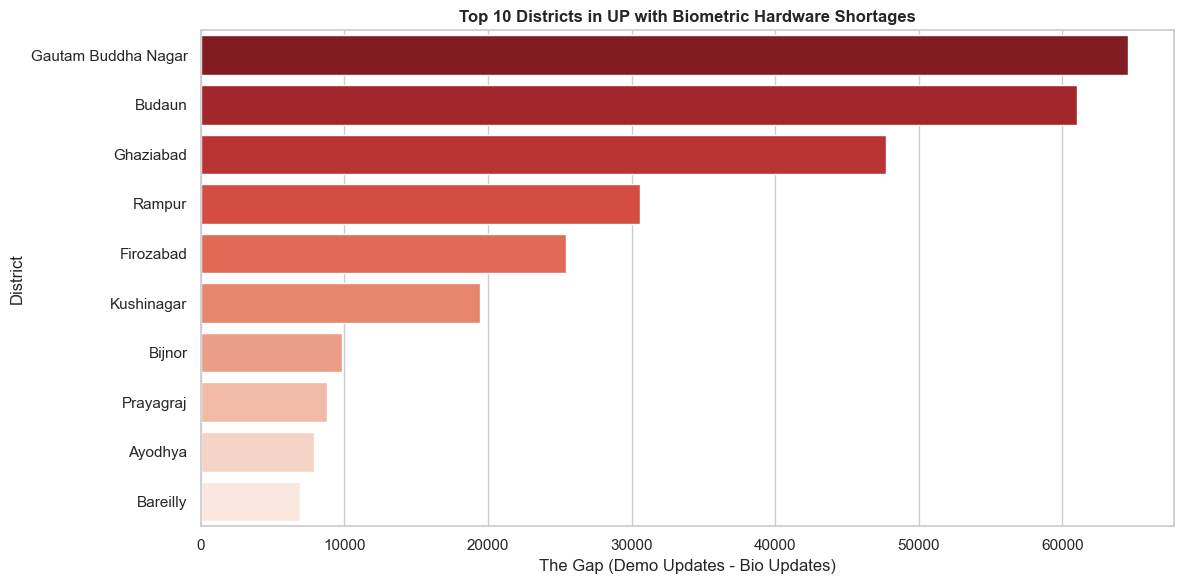

In [3]:
# 1. Filter for UP
df_up = df_master[df_master['state'] == 'Uttar Pradesh'].copy()

# 2. Aggregate by District
up_districts = df_up.groupby('district').agg({
    'total_demo_updates': 'sum',
    'total_bio_updates': 'sum'
}).reset_index()

# 3. Calculate the Gap
up_districts['gap'] = up_districts['total_demo_updates'] - up_districts['total_bio_updates']

# 4. Get Top 10 worst offenders
top_up_gaps = up_districts.nlargest(10, 'gap')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_up_gaps, x='gap', y='district', palette='Reds_r')
plt.title('Top 10 Districts in UP with Biometric Hardware Shortages', fontweight='bold')
plt.xlabel('The Gap (Demo Updates - Bio Updates)')
plt.ylabel('District')

save_figure(plt.gcf(), '05_up_district_hardware_gap')
plt.show()

In [4]:
print("Searching for Pincodes with 0 Biometric capability...")

# 1. Group by Pincode to get yearly totals
pin_summary = df_master.groupby(['state', 'district', 'pincode']).agg({
    'total_demo_updates': 'sum',
    'total_bio_updates': 'sum'
}).reset_index()

# 2. Filter for Deserts: High Demo updates (>500) but ZERO Bio updates
deserts = pin_summary[(pin_summary['total_bio_updates'] == 0) & (pin_summary['total_demo_updates'] > 500)]

# 3. Sort by total stranded citizens
top_deserts = deserts.sort_values('total_demo_updates', ascending=False).head(10)

print(f"Found {len(deserts)} Biometric Deserts across India.")
display(top_deserts)

Searching for Pincodes with 0 Biometric capability...
Found 0 Biometric Deserts across India.


,state,district,pincode,total_demo_updates,total_bio_updates


Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\06_enrolment_vs_update_correlation_20260407_032216.png


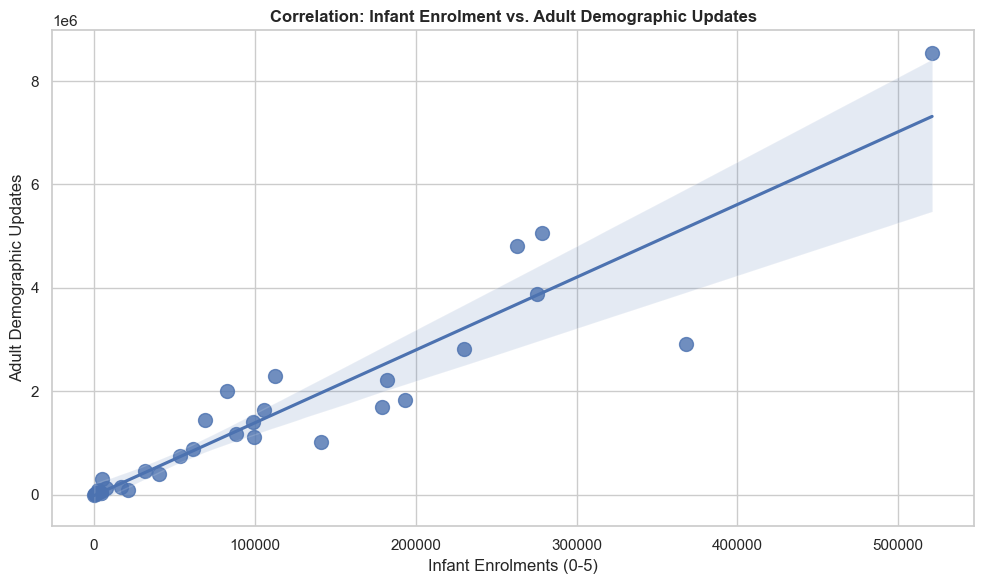

In [5]:
plt.figure(figsize=(10, 6))

# State-level summary
state_corr = df_master.groupby('state').agg({
    'age_0_5': 'sum',
    'total_demo_updates': 'sum'
}).reset_index()

sns.regplot(data=state_corr, x='age_0_5', y='total_demo_updates', scatter_kws={'s':100})
plt.title('Correlation: Infant Enrolment vs. Adult Demographic Updates', fontweight='bold')
plt.xlabel('Infant Enrolments (0-5)')
plt.ylabel('Adult Demographic Updates')

save_figure(plt.gcf(), '06_enrolment_vs_update_correlation')
plt.show()

In [6]:
# 1. Reuse our pin_summary from Cell 3
# Filter for pincodes with significant activity (>1000 total updates)
active_pins = pin_summary[pin_summary['total_demo_updates'] > 1000].copy()

# 2. Calculate Efficiency Ratio
active_pins['efficiency_ratio'] = active_pins['total_bio_updates'] / active_pins['total_demo_updates']

# 3. Find the 10 most "Strained" Pincodes in India
strained_pins = active_pins.sort_values('efficiency_ratio').head(10)

print("--- TOP 10 OVERWHELMED PINCODES (Lowest Bio-to-Demo Ratio) ---")
display(strained_pins[['state', 'district', 'pincode', 'efficiency_ratio', 'total_demo_updates']])

--- TOP 10 OVERWHELMED PINCODES (Lowest Bio-to-Demo Ratio) ---


,state,district,pincode,efficiency_ratio,total_demo_updates
25828,Telangana,Vikarabad,501158,0.017485,2688
21799,Tamil Nadu,Chengalpattu,600073,0.021739,1242
21810,Tamil Nadu,Chengalpattu,603103,0.023111,1125
21916,Tamil Nadu,Chennai,600099,0.037802,1984
6153,Chhattisgarh,Manendragarh–Chirmiri–Bharatpur,497442,0.041885,1337
6163,Chhattisgarh,Manendragarh–Chirmiri–Bharatpur,497778,0.044137,2311
30438,West Bengal,Koch Bihar,736176,0.057087,1016
30432,West Bengal,Koch Bihar,736170,0.063684,1900
24818,Telangana,Hanumakonda,506391,0.072816,1236
6283,Chhattisgarh,Sarangarh-Bilaigarh,496445,0.073213,2322


C:\Users\Asus\AppData\Local\Temp\ipykernel_18372\3720248326.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_risk, x='Compliance_Gap', y='state', palette='Oranges_r')


Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\07_mandatory_compliance_gap_20260407_032500.png


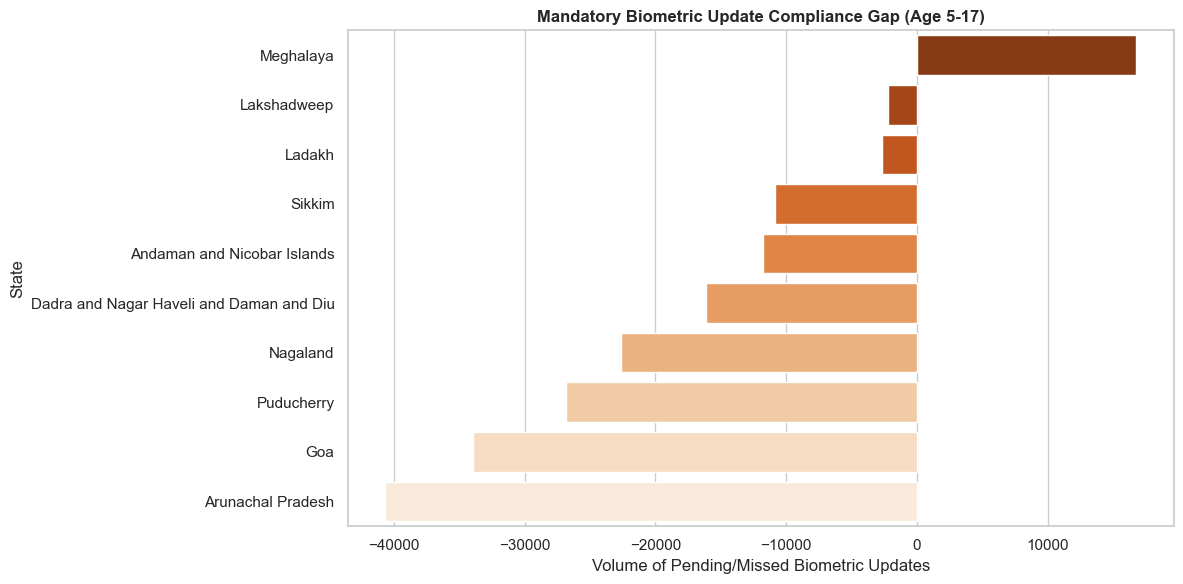

In [7]:
plt.figure(figsize=(12, 6))

# 1. Aggregate mandatory update columns
compliance_df = df_master.groupby('state').agg({
    'age_5_17': 'sum',           # New enrolments in this bracket
    'bio_age_5_17': 'sum'        # Mandatory biometric updates in this bracket
}).reset_index()

# 2. Calculate Gap
compliance_df['Compliance_Gap'] = compliance_df['age_5_17'] - compliance_df['bio_age_5_17']

# 3. Plot the Top 10 states with the largest compliance risk
top_risk = compliance_df.nlargest(10, 'Compliance_Gap')

sns.barplot(data=top_risk, x='Compliance_Gap', y='state', palette='Oranges_r')
plt.title('Mandatory Biometric Update Compliance Gap (Age 5-17)', fontweight='bold')
plt.xlabel('Volume of Pending/Missed Biometric Updates')
plt.ylabel('State')

save_figure(plt.gcf(), '07_mandatory_compliance_gap')
plt.show()